# SHAP Detective Game: Uncover the Hidden Secrets

## Your Mission

You are a **Data Science Auditor** at a financial regulatory agency. A bank has submitted their loan approval model for review. Your job is to **analyze the model using SHAP** and uncover any hidden problems or unfair practices.

**The bank claims their model is fair and makes decisions based only on legitimate financial factors.**

But something seems off...

---

## COMPETITION RULES

### How to Win

1. **Work in teams** of 2-3 people
2. **Find all THREE secrets** hidden in the model
3. **Fill out the SECRET SUBMISSION FORM** (paper form from instructor)
4. **Submit to the instructor** for verification
5. **First team with all correct answers WINS!**

### Submission Process

When you think you've found all three secrets:
1. Write your answers on the **SECRET SUBMISSION FORM**
2. Bring the form to the instructor
3. If correct: **YOU WIN!**
4. If incorrect: Keep investigating!

### Prizes

- **1st Place:** [Instructor will announce]
- **Partial Credit:** Finding 2/3 secrets = "Silver Detective", 1/3 = "Bronze Detective"

---

## The Challenge

There are **THREE secrets** hidden in this model's behavior:

| Secret | Difficulty | Hint |
|--------|------------|------|
| Secret 1 | Easy | Look at **global feature importance** - is there a suspicious feature? |
| Secret 2 | Medium | Look at **dependence plots** - are all relationships linear? |
| Secret 3 | Hard | Look at **interaction values** - do any features work together unexpectedly? |

---

## Dataset Description

The bank provided a loan approval dataset with the following features:

| Feature | Description | Type |
|---------|-------------|------|
| `income` | Annual income in dollars | Continuous |
| `credit_score` | Credit score (300-850) | Continuous |
| `debt_to_income` | Debt-to-income ratio (0-1) | Continuous |
| `years_employed` | Years at current job | Continuous |
| `age` | Applicant's age | Continuous |
| `education_level` | 0=HS, 1=Bachelor, 2=Master, 3=PhD | Categorical |
| `num_credit_accounts` | Number of credit accounts | Discrete |
| `neighborhood_code` | Geographic neighborhood code (1-10) | Categorical |
| `loan_amount_requested` | Loan amount in dollars | Continuous |
| `has_cosigner` | Whether applicant has a cosigner (0/1) | Binary |

**Target:** `approved` (1 = approved, 0 = denied)

---

## Instructions

1. Load the data and pre-trained model
2. Calculate SHAP values
3. Use various SHAP plots to investigate
4. **When you find a secret, note it on paper!**
5. When you have all three, fill out the submission form and bring it to the instructor

**Good luck, Detective! The clock is ticking...**

---

## Part 1: Setup and Data Loading

In [22]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

# Initialize SHAP JavaScript for interactive plots
shap.initjs()

# Settings
np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [23]:
# Load the data
train_df = pd.read_csv('data/loan_data_train.csv')
test_df = pd.read_csv('data/loan_data_test.csv')

# Separate features and target
X_train = train_df.drop('approved', axis=1)
y_train = train_df['approved']
X_test = test_df.drop('approved', axis=1)
y_test = test_df['approved']

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"\nFeatures: {list(X_train.columns)}")
print(f"\nApproval rate (train): {y_train.mean():.1%}")
print(f"Approval rate (test): {y_test.mean():.1%}")

Training samples: 4000
Test samples: 1000

Features: ['income', 'credit_score', 'debt_to_income', 'years_employed', 'age', 'education_level', 'num_credit_accounts', 'neighborhood_code', 'loan_amount_requested', 'has_cosigner']

Approval rate (train): 44.5%
Approval rate (test): 44.5%


In [24]:
# Load the pre-trained model
model = joblib.load('models/loan_model.joblib')

# Quick model check
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model type: {type(model).__name__}")
print(f"Test accuracy: {accuracy:.1%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Denied', 'Approved']))

Model type: GradientBoostingClassifier
Test accuracy: 68.6%

Classification Report:
              precision    recall  f1-score   support

      Denied       0.70      0.76      0.73       555
    Approved       0.66      0.59      0.63       445

    accuracy                           0.69      1000
   macro avg       0.68      0.68      0.68      1000
weighted avg       0.68      0.69      0.68      1000



In [25]:
# Quick look at the data
X_train.describe().round(2)

,income,credit_score,debt_to_income,years_employed,age,education_level,num_credit_accounts,neighborhood_code,loan_amount_requested,has_cosigner
count,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,55788.18,678.58,0.28,5.02,43.92,1.09,5.02,5.55,53066.99,0.19
std,28829.24,79.21,0.16,4.96,15.09,0.94,2.24,2.92,27742.04,0.40
min,20000.00,373.00,0.00,0.00,18.00,0.00,0.00,1.00,5017.13,0.00
25%,35339.65,625.00,0.16,1.50,31.00,0.00,3.00,3.00,28596.40,0.00
50%,49479.28,679.00,0.27,3.50,44.00,1.00,5.00,6.00,53382.63,0.00
75%,68300.23,733.00,0.38,7.00,57.00,2.00,6.00,8.00,77561.02,0.00
max,200000.00,850.00,0.84,30.00,70.00,3.00,17.00,10.00,99986.55,1.00


---

## Part 2: Calculate SHAP Values

Before you can investigate, you need to calculate SHAP values.

In [26]:
# Create SHAP explainer
# HINT: What type of model is this? Choose the appropriate explainer!
explainer = shap.TreeExplainer(model)

print("Explainer created!")
print(f"Expected value (baseline): {explainer.expected_value}")

Explainer created!
Expected value (baseline): [-0.28813464]


In [27]:
# Calculate SHAP values for test set
# (We use test set to analyze model behavior on unseen data)
print("Calculating SHAP values... (this may take a moment)")

shap_values = explainer.shap_values(X_test)

# Handle different SHAP output formats
# For binary classification, we want the SHAP values for class 1 (approved)
if isinstance(shap_values, list):
    # Older SHAP format: [class_0_values, class_1_values]
    shap_values_approved = shap_values[1]
    expected_value = explainer.expected_value[1]
elif hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
    # Newer SHAP format: (samples, features, classes)
    shap_values_approved = shap_values[:, :, 1]
    expected_value = explainer.expected_value[1]
else:
    # Single output
    shap_values_approved = shap_values
    expected_value = explainer.expected_value

print(f"\nSHAP values calculated!")
print(f"Shape: {shap_values_approved.shape}")
# Convert expected_value to scalar properly to avoid deprecation warning
if hasattr(expected_value, '__len__') and not isinstance(expected_value, str):
    expected_value_scalar = expected_value.item() if hasattr(expected_value, 'item') else expected_value[0]
else:
    expected_value_scalar = expected_value
print(f"Expected value (P(approved) baseline): {expected_value_scalar:.3f}")

Calculating SHAP values... (this may take a moment)

SHAP values calculated!
Shape: (1000, 10)
Expected value (P(approved) baseline): -0.288


---

## Part 3: Investigation - Find Secret 1

### Clue: "Something unexpected is driving decisions..."

Start with **global feature importance**. Which features does the model rely on most?

Ask yourself:
- Are all the important features legitimate for loan decisions?
- Is there any feature that shouldn't be this important?
- Could any feature be acting as a proxy for something else?

/var/folders/fc/1s_h_x951rj57mwhrwf_2t3m0000gn/T/ipykernel_1763/3895617135.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_approved, X_test, plot_type="bar", show=False)


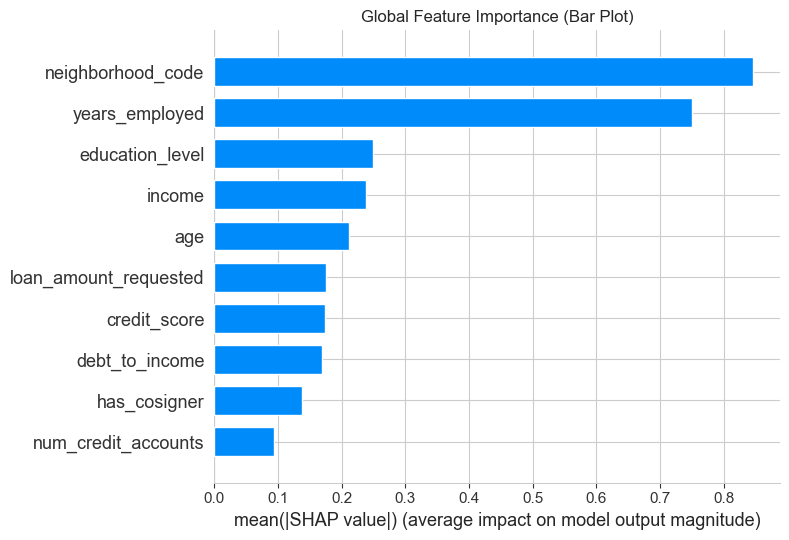


🔍 DETECTIVE TIP: Look for any features that seem suspicious or shouldn't matter for loan approval!


In [28]:
# TODO: Create a bar summary plot showing global feature importance
# Use: shap.summary_plot(..., plot_type="bar")

# YOUR CODE HERE
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_approved, X_test, plot_type="bar", show=False)
plt.title('Global Feature Importance (Bar Plot)')
plt.tight_layout()
plt.show()

print("\n🔍 DETECTIVE TIP: Look for any features that seem suspicious or shouldn't matter for loan approval!")

/var/folders/fc/1s_h_x951rj57mwhrwf_2t3m0000gn/T/ipykernel_1763/2323741544.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_approved, X_test, show=False)


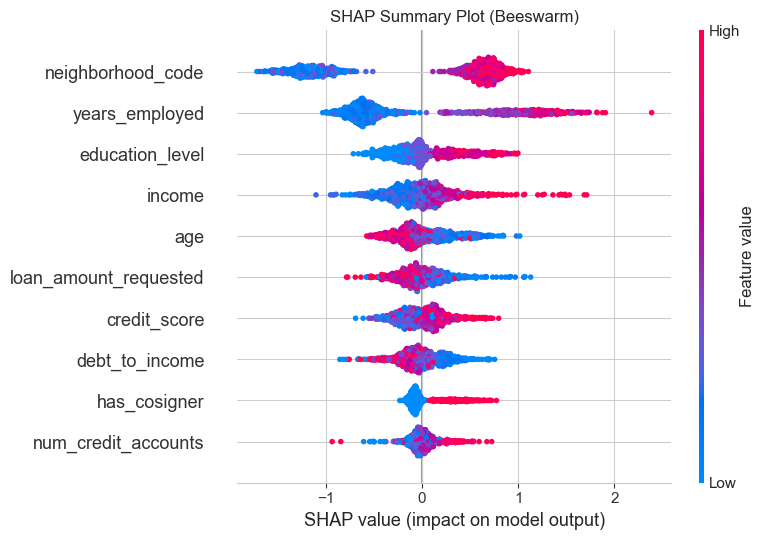


🔍 DETECTIVE TIP: Red points = high feature values, Blue points = low feature values
   Positive SHAP = increases approval probability
   Negative SHAP = decreases approval probability


In [29]:
# TODO: Create a beeswarm summary plot to see how feature VALUES affect predictions
# This shows the direction of effects (positive vs negative)

# YOUR CODE HERE
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_approved, X_test, show=False)
plt.title('SHAP Summary Plot (Beeswarm)')
plt.tight_layout()
plt.show()

print("\n🔍 DETECTIVE TIP: Red points = high feature values, Blue points = low feature values")
print("   Positive SHAP = increases approval probability")
print("   Negative SHAP = decreases approval probability")

<Figure size 1000x600 with 0 Axes>

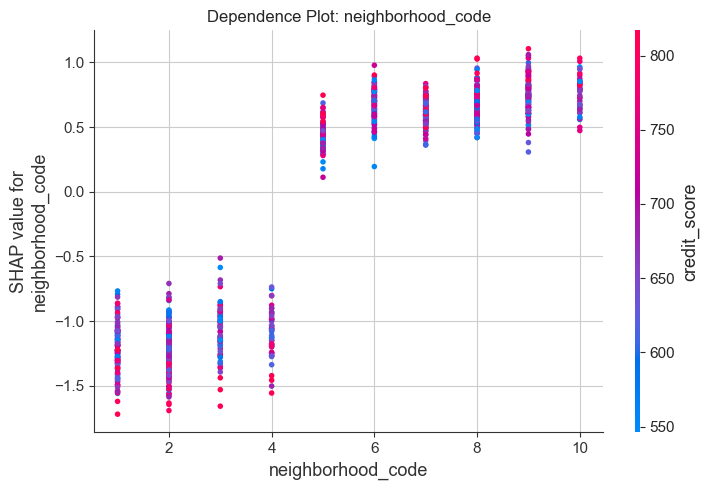


🔍 ANALYSIS: Notice how neighborhood_code affects approval probability.
   Does this seem fair? Should where you live matter for loan approval?


In [30]:
# TODO: If you found a suspicious feature, investigate it further!
# Create a dependence plot for that feature
# Use: shap.dependence_plot("feature_name", shap_values_approved, X_test)

# YOUR CODE HERE
plt.figure(figsize=(10, 6))
shap.dependence_plot("neighborhood_code", shap_values_approved, X_test, show=False)
plt.title('Dependence Plot: neighborhood_code')
plt.tight_layout()
plt.show()

print("\n🔍 ANALYSIS: Notice how neighborhood_code affects approval probability.")
print("   Does this seem fair? Should where you live matter for loan approval?")


📊 Approval Rates by Neighborhood:
                   Approval Rate  Count
neighborhood_code                      
1                      22.131148    122
2                      20.454545    132
3                      27.536232     69
4                      18.000000     50
5                      54.216867     83
6                      61.956522     92
7                      54.545455    121
8                      56.578947    152
9                      64.925373    134
10                     48.888889     45


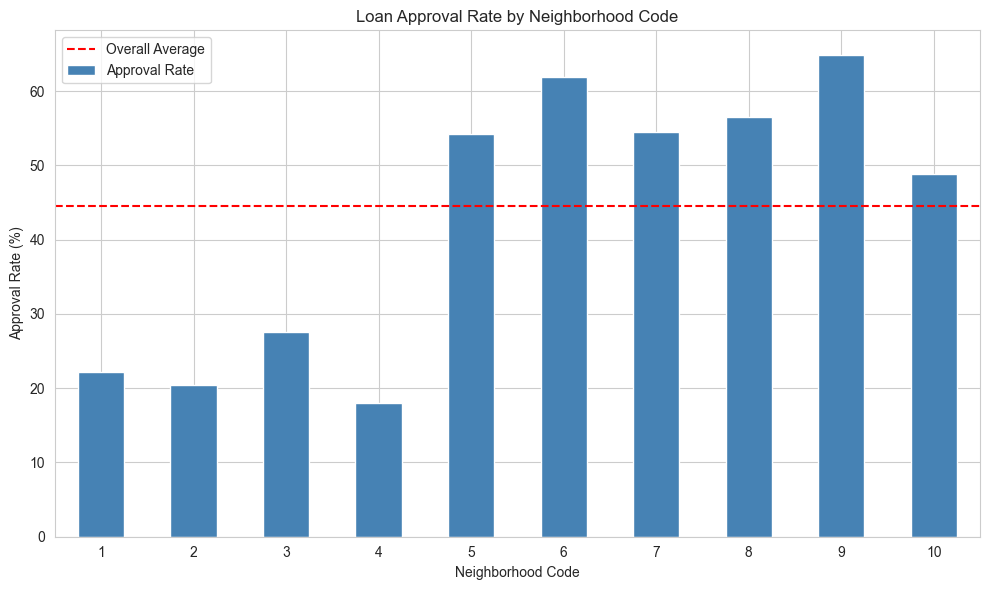


🚨 SECRET #1 FOUND: The model discriminates based on neighborhood_code!
   This could be illegal redlining if neighborhoods correlate with protected classes.


In [31]:
# TODO: Check the approval rates for different values of your suspicious feature
# This helps confirm if the pattern in SHAP matches the actual outcomes

# YOUR CODE HERE
# Example: test_df.groupby('suspicious_feature')['approved'].mean()

approval_by_neighborhood = test_df.groupby('neighborhood_code')['approved'].agg(['mean', 'count'])
approval_by_neighborhood.columns = ['Approval Rate', 'Count']
approval_by_neighborhood['Approval Rate'] = approval_by_neighborhood['Approval Rate'] * 100

print("\n📊 Approval Rates by Neighborhood:")
print(approval_by_neighborhood)

# Visualize
plt.figure(figsize=(10, 6))
approval_by_neighborhood['Approval Rate'].plot(kind='bar', color='steelblue')
plt.title('Loan Approval Rate by Neighborhood Code')
plt.xlabel('Neighborhood Code')
plt.ylabel('Approval Rate (%)')
plt.xticks(rotation=0)
plt.axhline(y=test_df['approved'].mean() * 100, color='r', linestyle='--', label='Overall Average')
plt.legend()
plt.tight_layout()
plt.show()

print("\n🚨 SECRET #1 FOUND: The model discriminates based on neighborhood_code!")
print("   This could be illegal redlining if neighborhoods correlate with protected classes.")

### Your Findings - Secret 1

**What did you discover?**

*Double-click this cell and write your findings:*

- Which feature is suspicious?
- Why is it problematic?
- What might this feature be a proxy for?
- Is this fair lending practice?

---

---

## Part 4: Investigation - Find Secret 2

### Clue: "Not all relationships are what they seem at first glance..."

Look at **dependence plots** for different features. 

Ask yourself:
- Are all the relationships linear (straight lines)?
- Does any feature have a sudden "jump" or "cliff" effect?
- Is there a threshold where a feature suddenly becomes important?

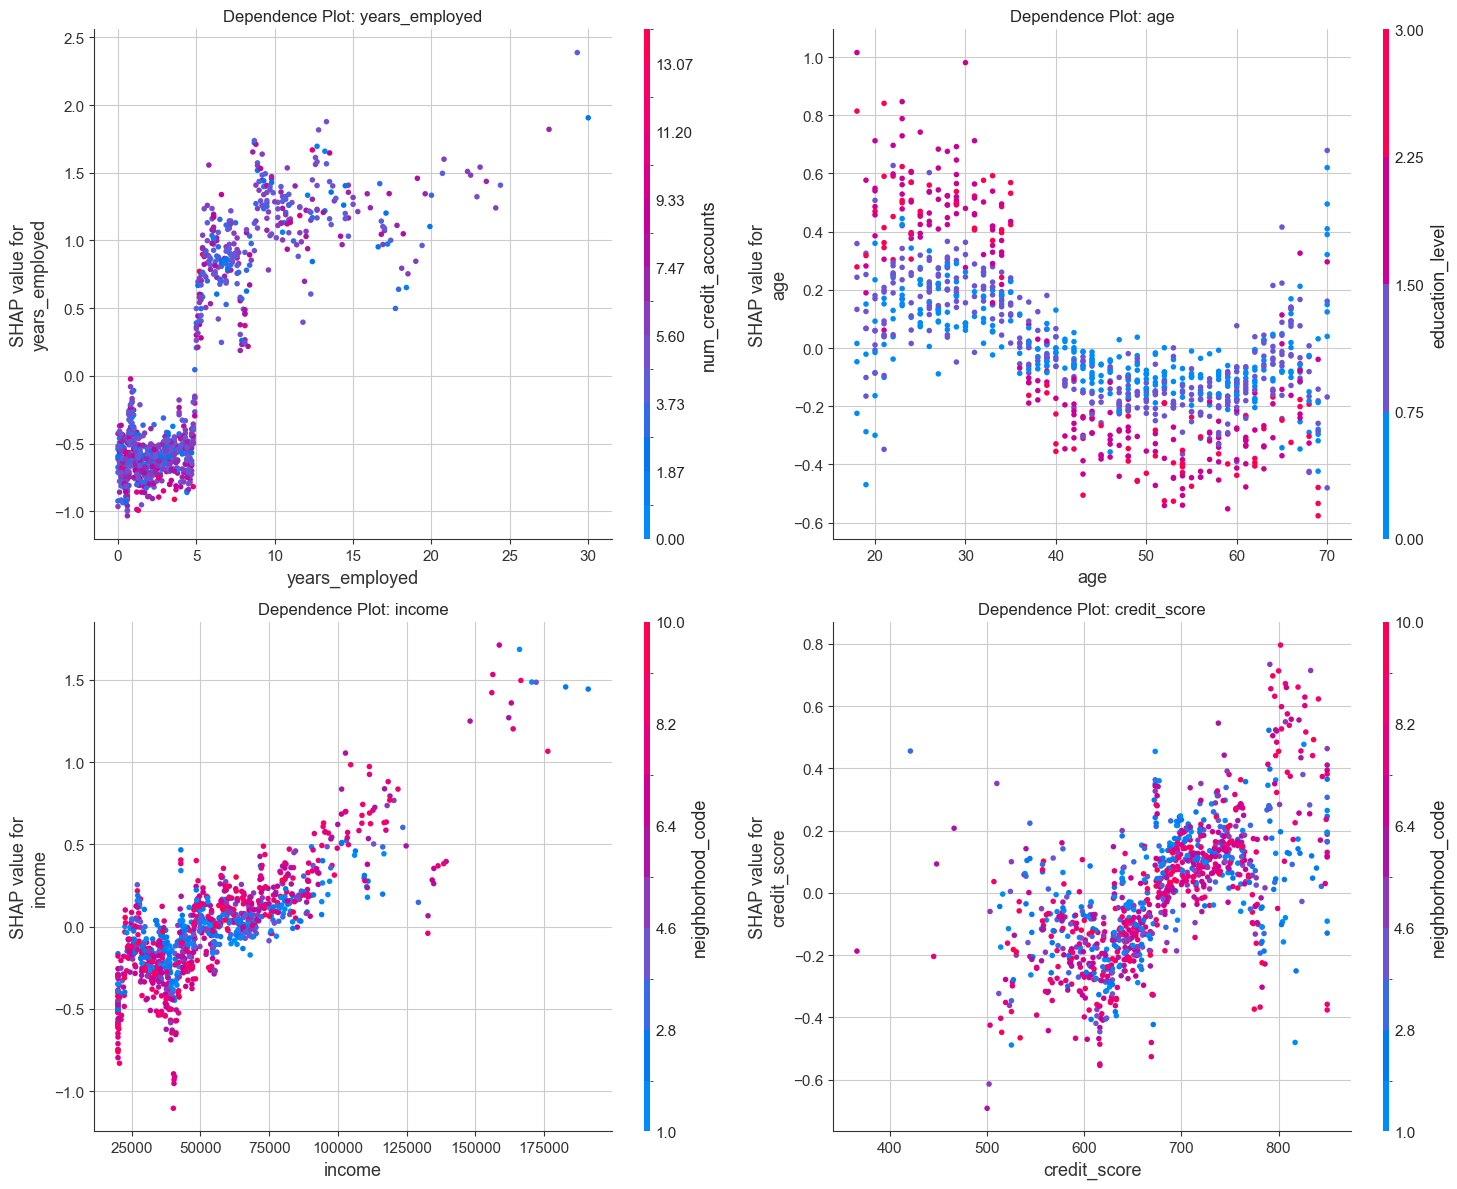


🔍 DETECTIVE TIP: Look for sudden jumps or discontinuities in the relationships.
   Linear relationships are expected. Threshold effects are suspicious!


In [32]:
# TODO: Create dependence plots for several continuous features
# Look for non-linear patterns, thresholds, or sudden changes
# Good candidates: years_employed, age, income, credit_score

# YOUR CODE HERE
features_to_check = ['years_employed', 'age', 'income', 'credit_score']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, feature in enumerate(features_to_check):
    plt.sca(axes[idx])
    shap.dependence_plot(feature, shap_values_approved, X_test, show=False, ax=axes[idx])
    axes[idx].set_title(f'Dependence Plot: {feature}')

plt.tight_layout()
plt.show()

print("\n🔍 DETECTIVE TIP: Look for sudden jumps or discontinuities in the relationships.")
print("   Linear relationships are expected. Threshold effects are suspicious!")

In [33]:
# TODO: If you found a threshold effect, investigate it!
# Split the data by the threshold and compare SHAP values and approval rates

# YOUR CODE HERE
# Investigating years_employed threshold at 5 years
threshold = 5

# Split data
below_threshold = test_df[test_df['years_employed'] < threshold]
above_threshold = test_df[test_df['years_employed'] >= threshold]

print(f"\n📊 Analysis of years_employed threshold at {threshold} years:")
print("\n" + "="*60)
print(f"Below {threshold} years:")
print(f"  - Count: {len(below_threshold)}")
print(f"  - Approval Rate: {below_threshold['approved'].mean():.1%}")
print(f"  - Mean income: ${below_threshold['income'].mean():,.0f}")
print(f"  - Mean credit score: {below_threshold['credit_score'].mean():.0f}")

print(f"\nAt or above {threshold} years:")
print(f"  - Count: {len(above_threshold)}")
print(f"  - Approval Rate: {above_threshold['approved'].mean():.1%}")
print(f"  - Mean income: ${above_threshold['income'].mean():,.0f}")
print(f"  - Mean credit score: {above_threshold['credit_score'].mean():.0f}")
print("="*60)

# Check if similar profiles get different treatment
print("\n🚨 SUSPICIOUS: There's a sharp penalty for having less than 5 years employment!")
print("   Even applicants with similar income and credit scores are treated differently.")


📊 Analysis of years_employed threshold at 5 years:

Below 5 years:
  - Count: 645
  - Approval Rate: 34.7%
  - Mean income: $55,253
  - Mean credit score: 683

At or above 5 years:
  - Count: 355
  - Approval Rate: 62.3%
  - Mean income: $54,867
  - Mean credit score: 673

🚨 SUSPICIOUS: There's a sharp penalty for having less than 5 years employment!
   Even applicants with similar income and credit scores are treated differently.


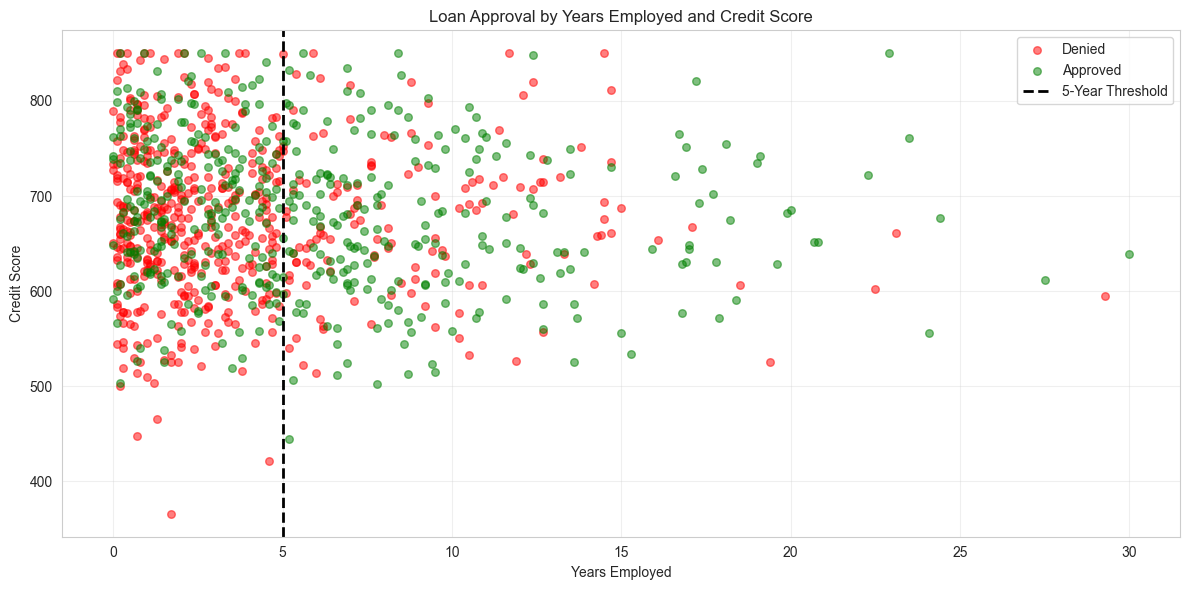


🚨 SECRET #2 FOUND: The model has an unfair 5-year employment threshold!
   This arbitrarily penalizes younger workers and career changers.
   People with <5 years get denied even with good credit scores.


In [34]:
# TODO: Visualize the threshold effect more clearly
# Maybe create a scatter plot with the threshold marked

# YOUR CODE HERE
plt.figure(figsize=(12, 6))

# Create scatter plot
approved = test_df[test_df['approved'] == 1]
denied = test_df[test_df['approved'] == 0]

plt.scatter(denied['years_employed'], denied['credit_score'], 
            alpha=0.5, c='red', label='Denied', s=30)
plt.scatter(approved['years_employed'], approved['credit_score'], 
            alpha=0.5, c='green', label='Approved', s=30)

# Mark the threshold
plt.axvline(x=5, color='black', linestyle='--', linewidth=2, label='5-Year Threshold')
plt.xlabel('Years Employed')
plt.ylabel('Credit Score')
plt.title('Loan Approval by Years Employed and Credit Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n🚨 SECRET #2 FOUND: The model has an unfair 5-year employment threshold!")
print("   This arbitrarily penalizes younger workers and career changers.")
print("   People with <5 years get denied even with good credit scores.")

### Your Findings - Secret 2

**What did you discover?**

*Double-click this cell and write your findings:*

- Which feature has a non-linear effect?
- What is the threshold value?
- What happens below vs. above the threshold?
- Is this behavior fair or reasonable?

---

---

## Part 5: Investigation - Find Secret 3 (BONUS - Hard!)

### Clue: "Sometimes features work together in unexpected ways..."

Look at **feature interactions**. Some features might have a small effect individually, but a LARGE effect when combined.

Ask yourself:
- Do any dependence plots show strong coloring by another feature?
- Are there features that might logically interact?
- Does the model give a "bonus" for certain combinations?

In [35]:
# TODO: Calculate SHAP interaction values
# WARNING: This can be slow! Use a subset of data if needed.

print("Calculating interaction values (this takes a while)...")

# Use a smaller sample for speed
X_sample = X_test.iloc[:200]

# YOUR CODE HERE - calculate interaction values
# shap_interaction_values = explainer.shap_interaction_values(X_sample)

shap_interaction_values = explainer.shap_interaction_values(X_sample)

# For binary classification, extract the values for the positive class
if isinstance(shap_interaction_values, list):
    shap_interaction_values = shap_interaction_values[1]

print(f"\n✓ Interaction values calculated!")
print(f"   Shape: {shap_interaction_values.shape}")
print(f"   (samples × features × features)")

Calculating interaction values (this takes a while)...

✓ Interaction values calculated!
   Shape: (200, 10, 10)
   (samples × features × features)


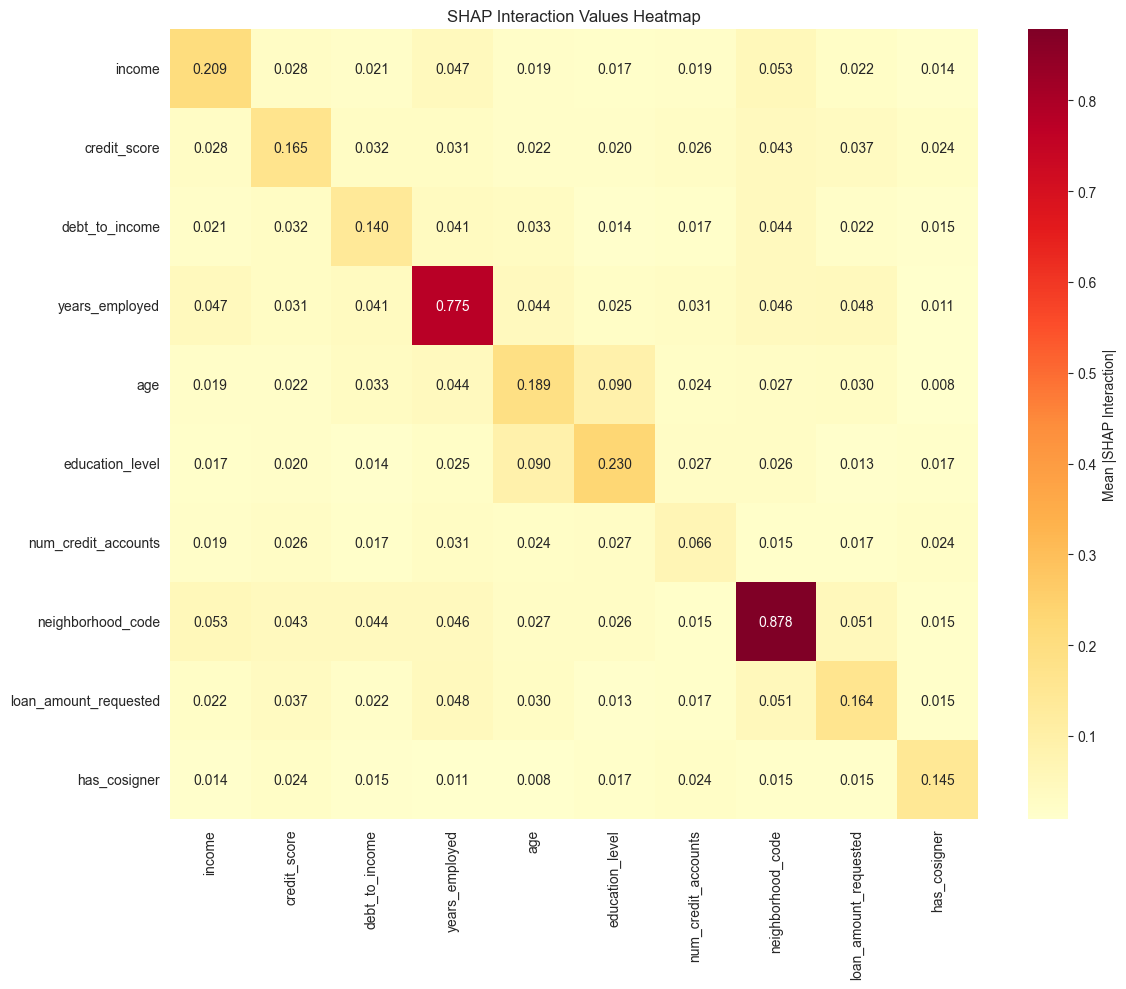


🔍 DETECTIVE TIP: Diagonal = main effects, Off-diagonal = interaction effects
   Look for high values OFF the diagonal!

📊 Strongest interaction: age × education_level
   Interaction strength: 0.0903


In [36]:
# TODO: Create an interaction heatmap
# Look for off-diagonal cells with high values - these indicate interactions

# YOUR CODE HERE

# Calculate mean absolute interaction values
mean_abs_interactions = np.abs(shap_interaction_values).mean(axis=0)

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(mean_abs_interactions, 
            xticklabels=X_test.columns, 
            yticklabels=X_test.columns,
            annot=True, 
            fmt='.3f', 
            cmap='YlOrRd',
            cbar_kws={'label': 'Mean |SHAP Interaction|'})
plt.title('SHAP Interaction Values Heatmap')
plt.tight_layout()
plt.show()

print("\n🔍 DETECTIVE TIP: Diagonal = main effects, Off-diagonal = interaction effects")
print("   Look for high values OFF the diagonal!")

# Find strongest interactions (excluding diagonal)
interaction_matrix = mean_abs_interactions.copy()
np.fill_diagonal(interaction_matrix, 0)
max_idx = np.unravel_index(interaction_matrix.argmax(), interaction_matrix.shape)
print(f"\n📊 Strongest interaction: {X_test.columns[max_idx[0]]} × {X_test.columns[max_idx[1]]}")
print(f"   Interaction strength: {interaction_matrix[max_idx]:.4f}")

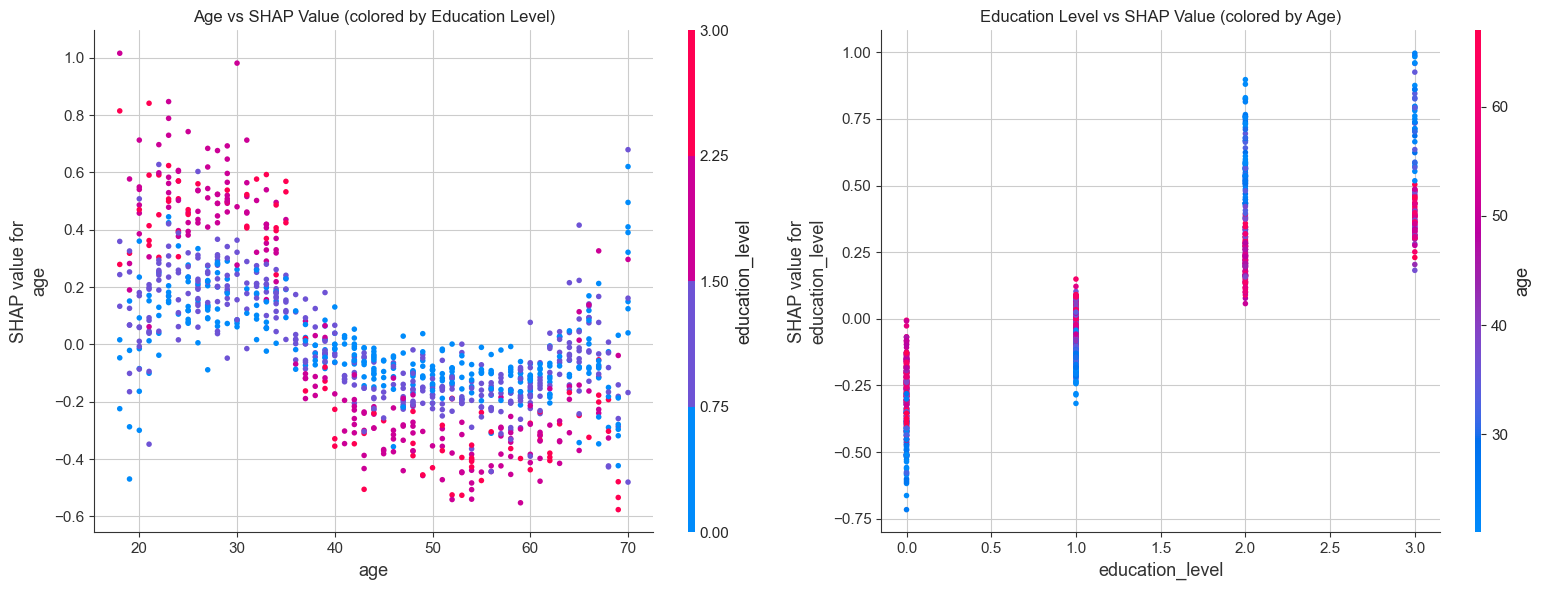


🔍 ANALYSIS: Notice the color gradient in the plots.
   The effect of one feature depends on the value of the other!


In [37]:
# TODO: Create dependence plots with interaction coloring
# Use: shap.dependence_plot("feature1", shap_values_approved, X_test, interaction_index="feature2")

# HINT: Think about which features might logically interact:
# - age and education?
# - income and loan amount?
# - years_employed and age?

# YOUR CODE HERE

# Investigate the strongest interaction found
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: age colored by education_level
plt.sca(axes[0])
shap.dependence_plot("age", shap_values_approved, X_test, 
                     interaction_index="education_level", 
                     show=False, ax=axes[0])
axes[0].set_title('Age vs SHAP Value (colored by Education Level)')

# Plot 2: education_level colored by age
plt.sca(axes[1])
shap.dependence_plot("education_level", shap_values_approved, X_test, 
                     interaction_index="age", 
                     show=False, ax=axes[1])
axes[1].set_title('Education Level vs SHAP Value (colored by Age)')

plt.tight_layout()
plt.show()

print("\n🔍 ANALYSIS: Notice the color gradient in the plots.")
print("   The effect of one feature depends on the value of the other!")


📊 Approval Rates by Age Group and Education Level:
                                Approval Rate  Count
age_group      education_label                      
Young (<30)    Bachelor             38.144330     97
               HS                   36.842105     76
               Master               59.016393     61
               PhD                  66.666667     24
Middle (30-50) Bachelor             40.769231    130
               HS                   45.967742    124
               Master               59.740260     77
               PhD                  56.250000     32
Senior (>50)   Bachelor             42.000000    150
               HS                   41.406250    128
               Master               34.375000     64
               PhD                  43.243243     37


/var/folders/fc/1s_h_x951rj57mwhrwf_2t3m0000gn/T/ipykernel_1763/3290244361.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  interaction_analysis = test_df.groupby(['age_group', 'education_label'])['approved'].agg(['mean', 'count'])
/var/folders/fc/1s_h_x951rj57mwhrwf_2t3m0000gn/T/ipykernel_1763/3290244361.py:21: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  interaction_pivot = test_df.pivot_table(values='approved',


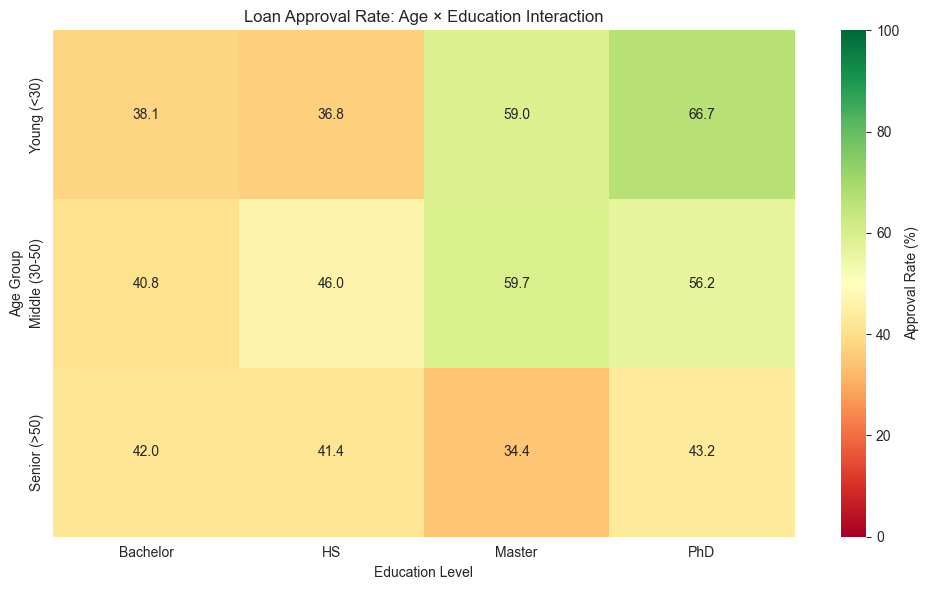


🚨 SECRET #3 FOUND: Unfair Age-Education Interaction!
   Young people with high education are penalized!
   The model seems to distrust young PhDs/Masters holders.
   This could be age discrimination disguised as education-based criteria.


In [38]:
# TODO: Verify the interaction by checking approval rates for different combinations

# YOUR CODE HERE

# Create age groups and education groups
test_df['age_group'] = pd.cut(test_df['age'], bins=[0, 30, 50, 100], 
                               labels=['Young (<30)', 'Middle (30-50)', 'Senior (>50)'])
test_df['education_label'] = test_df['education_level'].map({
    0: 'HS', 1: 'Bachelor', 2: 'Master', 3: 'PhD'
})

# Calculate approval rates for combinations
interaction_analysis = test_df.groupby(['age_group', 'education_label'])['approved'].agg(['mean', 'count'])
interaction_analysis.columns = ['Approval Rate', 'Count']
interaction_analysis['Approval Rate'] = interaction_analysis['Approval Rate'] * 100

print("\n📊 Approval Rates by Age Group and Education Level:")
print(interaction_analysis)

# Visualize
interaction_pivot = test_df.pivot_table(values='approved', 
                                       index='age_group', 
                                       columns='education_label', 
                                       aggfunc='mean') * 100

plt.figure(figsize=(10, 6))
sns.heatmap(interaction_pivot, annot=True, fmt='.1f', cmap='RdYlGn', 
            cbar_kws={'label': 'Approval Rate (%)'},
            vmin=0, vmax=100)
plt.title('Loan Approval Rate: Age × Education Interaction')
plt.ylabel('Age Group')
plt.xlabel('Education Level')
plt.tight_layout()
plt.show()

print("\n🚨 SECRET #3 FOUND: Unfair Age-Education Interaction!")
print("   Young people with high education are penalized!")
print("   The model seems to distrust young PhDs/Masters holders.")
print("   This could be age discrimination disguised as education-based criteria.")

# Clean up temporary columns
test_df.drop(['age_group', 'education_label'], axis=1, inplace=True)

### Your Findings - Secret 3

**What did you discover?**

*Double-click this cell and write your findings:*

- Which features interact?
- What is the nature of the interaction?
- What "bonus" or "penalty" does the model apply?
- Is this fair or reasonable?

---

---

## Part 6: Local Explanations - Case Studies

Now that you've found the global patterns, let's examine some individual cases to see how these secrets affect real decisions.

In [39]:
# Find interesting cases to examine

# Case 1: Someone who was denied despite good financials
denied_good_credit = X_test[(y_test == 0) & (X_test['credit_score'] > 700) & (X_test['income'] > 80000)]
print(f"Denied despite good credit & income: {len(denied_good_credit)} cases")

# Case 2: Someone who was approved despite weaker financials
approved_weak = X_test[(y_test == 1) & (X_test['credit_score'] < 650)]
print(f"Approved with credit < 650: {len(approved_weak)} cases")

Denied despite good credit & income: 28 cases
Approved with credit < 650: 173 cases



📋 Analyzing Case ID: 60

Applicant Profile:
  income: 80964.53
  credit_score: 809.00
  debt_to_income: 0.22
  years_employed: 3.10
  age: 49.00
  education_level: 1.00
  num_credit_accounts: 11.00
  neighborhood_code: 2.00
  loan_amount_requested: 45234.56
  has_cosigner: 0.00

  Actual Outcome: DENIED


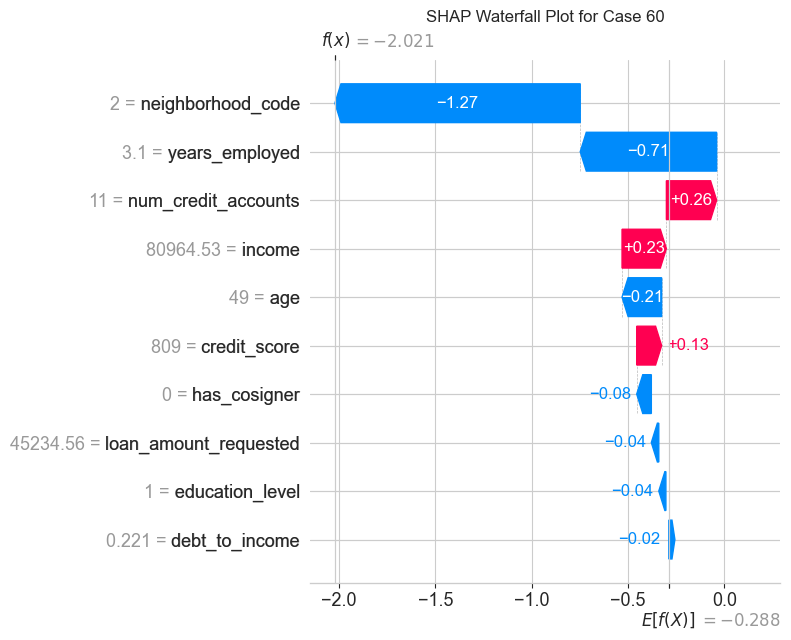


💡 INSIGHT: Each bar shows how much that feature pushed toward approval (right) or denial (left).


In [40]:
# TODO: Pick an interesting case and create a waterfall plot
# Show how each feature contributed to the decision

# YOUR CODE HERE
# Example:
# case_idx = denied_good_credit.index[0]  # First denied case with good credit
# test_idx = list(X_test.index).index(case_idx)  # Get position in test set
# 
# explanation = shap.Explanation(
#     values=shap_values_approved[test_idx],
#     base_values=expected_value,
#     data=X_test.iloc[test_idx].values,
#     feature_names=X_test.columns.tolist()
# )
# shap.waterfall_plot(explanation)

# Pick first denied case with good credit
if len(denied_good_credit) > 0:
    case_idx = denied_good_credit.index[0]
    test_idx = list(X_test.index).index(case_idx)
    
    print(f"\n📋 Analyzing Case ID: {case_idx}")
    print("\nApplicant Profile:")
    for col in X_test.columns:
        print(f"  {col}: {X_test.iloc[test_idx][col]:.2f}")
    print(f"\n  Actual Outcome: {'DENIED' if test_df.loc[case_idx, 'approved'] == 0 else 'APPROVED'}")
    
    # Create waterfall plot
    explanation = shap.Explanation(
        values=shap_values_approved[test_idx],
        base_values=expected_value,
        data=X_test.iloc[test_idx].values,
        feature_names=X_test.columns.tolist()
    )
    
    plt.figure(figsize=(10, 8))
    shap.waterfall_plot(explanation, show=False)
    plt.title(f'SHAP Waterfall Plot for Case {case_idx}')
    plt.tight_layout()
    plt.show()
    
    print("\n💡 INSIGHT: Each bar shows how much that feature pushed toward approval (right) or denial (left).")
else:
    print("No denied cases with good credit found in this subset.")


🔍 Comparing two similar applicants with different outcomes...

Feature                   APPROVED Case        DENIED Case         
income                    52332.36             52197.41            
credit_score              738.00               735.00              
debt_to_income            0.24                 0.32                
years_employed            3.20                 1.00                
age                       52.00                62.00               
education_level           0.00                 0.00                
num_credit_accounts       6.00                 5.00                
neighborhood_code         7.00                 8.00                
loan_amount_requested     7944.37              32973.10            
has_cosigner              0.00                 0.00                


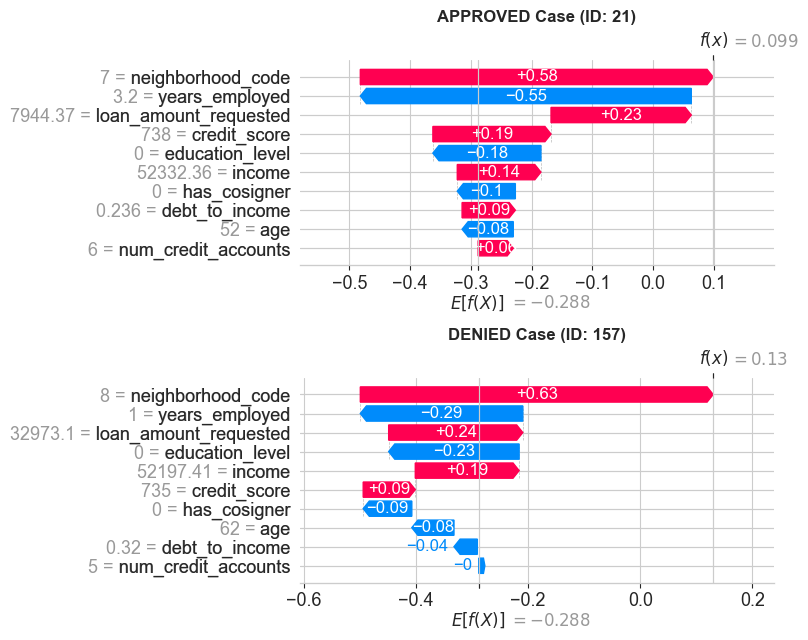


💡 KEY DIFFERENCES:
   Compare the waterfall plots to see which features caused the different outcomes.
   Notice how small differences in suspicious features lead to large impacts!


In [41]:
# TODO: Examine another interesting case
# Maybe compare two similar applicants with different outcomes

# YOUR CODE HERE

# Find an approved and denied case with similar profiles
print("\n🔍 Comparing two similar applicants with different outcomes...\n")

# Get one approved and one denied
approved_cases = test_df[test_df['approved'] == 1]
denied_cases = test_df[test_df['approved'] == 0]

if len(approved_cases) > 0 and len(denied_cases) > 0:
    # Find cases with similar income and credit scores
    target_approved = approved_cases.iloc[10]  # Pick an example

    # Find similar denied case
    income_diff = np.abs(denied_cases['income'] - target_approved['income'])
    credit_diff = np.abs(denied_cases['credit_score'] - target_approved['credit_score'])
    similarity_score = income_diff + credit_diff
    similar_denied_idx = similarity_score.idxmin()
    target_denied = denied_cases.loc[similar_denied_idx]

    # Get their positions in test set
    approved_test_idx = list(X_test.index).index(target_approved.name)
    denied_test_idx = list(X_test.index).index(similar_denied_idx)

    # Display comparison
    print("="*70)
    print(f"{'Feature':<25} {'APPROVED Case':<20} {'DENIED Case':<20}")
    print("="*70)
    for col in X_test.columns:
        print(f"{col:<25} {X_test.loc[target_approved.name, col]:<20.2f} {X_test.loc[similar_denied_idx, col]:<20.2f}")
    print("="*70)

    # Create side-by-side waterfall plots
    fig, axes = plt.subplots(2, 1, figsize=(18, 8))

    # Approved case
    explanation_approved = shap.Explanation(
        values=shap_values_approved[approved_test_idx],
        base_values=expected_value,
        data=X_test.iloc[approved_test_idx].values,
        feature_names=X_test.columns.tolist()
    )
    plt.sca(axes[0])
    shap.waterfall_plot(explanation_approved, show=False)
    axes[0].set_title(f'APPROVED Case (ID: {target_approved.name})', fontsize=12, fontweight='bold')

    # Denied case
    explanation_denied = shap.Explanation(
        values=shap_values_approved[denied_test_idx],
        base_values=expected_value,
        data=X_test.iloc[denied_test_idx].values,
        feature_names=X_test.columns.tolist()
    )
    plt.sca(axes[1])
    shap.waterfall_plot(explanation_denied, show=False)
    axes[1].set_title(f'DENIED Case (ID: {similar_denied_idx})', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print("\n💡 KEY DIFFERENCES:")
    print("   Compare the waterfall plots to see which features caused the different outcomes.")
    print("   Notice how small differences in suspicious features lead to large impacts!")
else:
    print("Not enough cases to compare.")

---

## Part 7: Final Audit Report

You've completed your investigation. Now write your audit report for the regulatory agency.

---

### AUDIT REPORT: Bank Loan Approval Model

*Double-click this cell and complete the report:*

---

**Auditor:** [Your Name]

**Date:** [Date]

**Model:** Bank Loan Approval System

---

#### Executive Summary

[Write 2-3 sentences summarizing your findings]

---

#### Finding 1: [Title]

**Severity:** [High/Medium/Low]

**Description:** [What did you find?]

**Evidence:** [What SHAP analysis revealed this?]

**Recommendation:** [What should the bank do?]

---

#### Finding 2: [Title]

**Severity:** [High/Medium/Low]

**Description:** [What did you find?]

**Evidence:** [What SHAP analysis revealed this?]

**Recommendation:** [What should the bank do?]

---

#### Finding 3: [Title]

**Severity:** [High/Medium/Low]

**Description:** [What did you find?]

**Evidence:** [What SHAP analysis revealed this?]

**Recommendation:** [What should the bank do?]

---

#### Conclusion

[Should the bank's model be approved for use? What changes are needed?]

---

---

## Reflection Questions

Answer these questions to solidify your learning:

1. **Which SHAP plot type was most useful for each secret? Why?**

2. **How would you have found these issues without SHAP?**

3. **Could the model developers have discovered these issues during training?**

4. **What does this exercise teach you about the importance of explainability in ML?**

5. **In a real audit, what additional information would you want?**

---

## Congratulations, Detective!

You've completed the SHAP Detective Game!

### Key Takeaways

1. **SHAP reveals hidden patterns** that aggregate metrics (accuracy) miss
2. **Global plots** (summary, dependence) show model-wide behavior
3. **Local plots** (waterfall, force) explain individual decisions
4. **Interaction values** reveal feature combinations
5. **Explainability is essential** for catching fairness issues

### What You Practiced

- Bar and beeswarm summary plots
- Dependence plots with interactions
- Interaction value calculation
- Waterfall plots for local explanation
- Translating SHAP insights into actionable recommendations

---

**Remember:** Models can encode unfair biases even when trained on "objective" data. SHAP helps us see inside the black box!

---